# Step 2：模块二 — 数据质量检测与根因定位

## 痛点故事

**幕一**：小白看到模块一评分卡「SAP C 等级」，跑去找问题，**2 天**才定位到几个订单，会议上说不清。

**幕二**：同一份 C 等级，notebook **5 分钟**告诉他「6 万条孤儿行集中在物料前缀 501/502，样本订单号 0001234567/0001234568…，责任部门=销售部」。

## 目录

1. [3 步学习节奏](#3-步学习节奏)
2. [步骤 1：GE 规则引擎全量扫描](#步骤-1ge-规则引擎全量扫描)
3. [步骤 2：4 类根因定位](#步骤-24-类根因定位)
4. [步骤 3：告警聚合 + 处置优先级](#步骤-3告警聚合--处置优先级)
5. [附加：JSON 报告生成与复用](#附加json-报告生成与复用)
6. [模块二总结](#模块二总结)

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────
# 把 src/ 加入 Python 路径
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import pandas as pd
from dg_education import (
    run_ge_scan,
    analyze_vbap_invalid_links,
    analyze_pi_missing_tags,
    analyze_pi_anomalies,
    analyze_lims_ad_outliers,
    plot_system_alert_summary,
    plot_root_cause_distribution,
    plot_alert_heatmap,
)

# 历史数据根目录（用 2022 年全量数据）
DATA_ROOT = os.path.join(os.path.dirname(os.getcwd()), 'data', 'historical')
print(f"DATA_ROOT = {DATA_ROOT}")
print(f"已加载 8 个新 API (模块二)")


DATA_ROOT = /home/szs/Playground/dg-demo/data/historical
已加载 8 个新 API (模块二)


## 3 步学习节奏

本模块分 3 步走完：

| 步骤 | 目标 | 核心概念 |
|------|------|----------|
| 步骤 1 | 看见「哪里出问题了」 | GE 规则引擎全量扫描，A/B/C/D 等级 + 失败规则 |
| 步骤 2 | 定位「具体是谁」 | 4 类根因：SAP 孤儿行 / PI 缺失 / PI 异常突升 / LIMS 灰分 |
| 步骤 3 | 排序「先处理谁」 | 告警热力图 + 责任部门归属 + 处置优先级 |

走完这 3 步，你就掌握了「数据治理第二步」：**从「有评分」到「能定位」的自动化**。

> **与模块一的关系**：模块一教「看资产、评分卡」，模块二教「**找具体问题**」。
> 模块一是模块二的前置基础，但模块二可独立运行（不依赖模块一）。

## 步骤 1：GE 规则引擎全量扫描

**为什么从这里开始？** 模块一只告诉你「SAP 评分 C」，但「为什么是 C、哪条规则失败」
需要 GE 规则引擎跑出来。这一步等同于「体检报告」——列出每条规则的 PASS / FAIL。

GE 扫描封装在 `run_ge_scan()`（同进程 import + numpy 类型规范化），
执行引擎是 pandas 轻量级实现（教学用），规则定义见 `scripts/run_great_expectations.py` 的 RULES 字典。

In [2]:
# 跑全量 GE 扫描（4 系统 / 6 张表 / 26 条规则）
report = run_ge_scan()
print(f"扫描时间: {report['timestamp']}")
print(f"耗时: {report.get('elapsed_seconds', '?')}s")
print(f"综合平均分: {report['overall_avg_score']}")
print()
print("=== 评分汇总 ===")
for s in report['summary']:
    print(f"  {s['system']:<15} {s['score']:>6.1f}  ({s['grade']})  失败 {s['failed']} 条规则")


扫描时间: 2026-06-12T14:41:14.765647
耗时: 2.1s
综合平均分: 64.9

=== 评分汇总 ===
  sap_erp           73.3  (C)  失败 4 条规则
  pi_system         40.0  (D)  失败 3 条规则
  lims              71.4  (C)  失败 2 条规则
  oa                75.0  (C)  失败 1 条规则


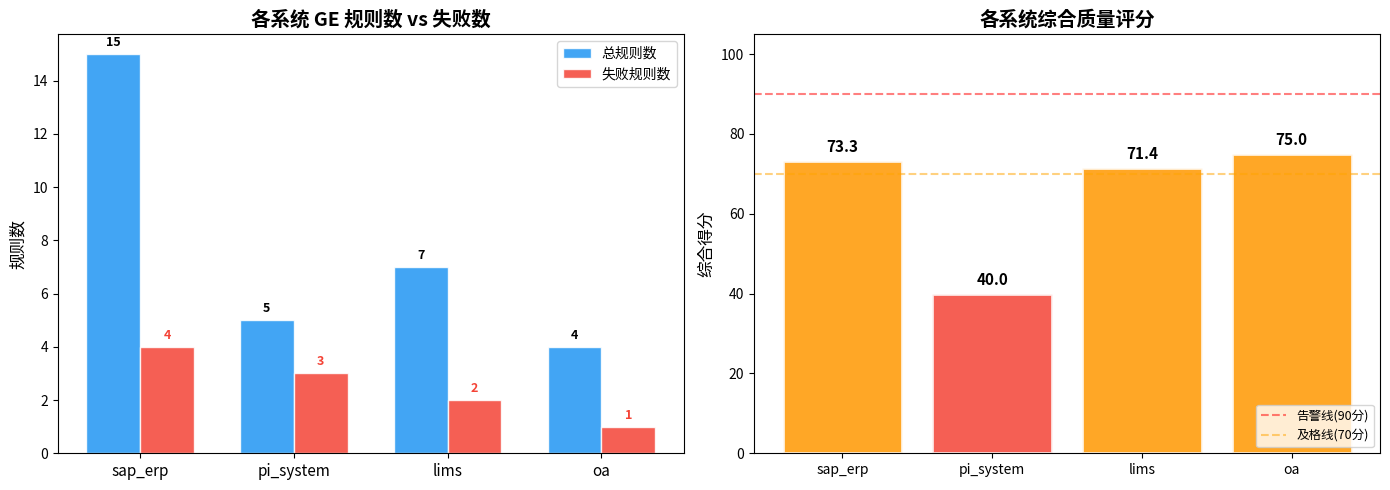

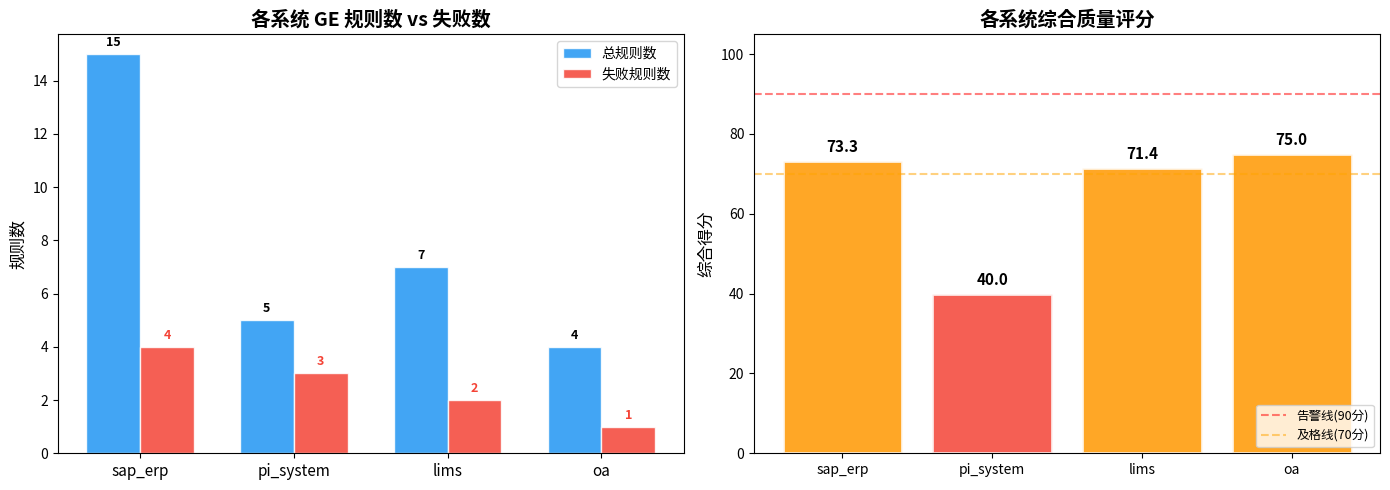

In [3]:
# 可视化：双柱状对比 + 评分排名
fig = plot_system_alert_summary(report)
fig


In [4]:
# 展开看每张表的失败规则（让小白知道「具体哪条规则 FAIL」）
print("=== 失败规则详情 ===\n")
for sys_name, sys_results in report['results'].items():
    for t in sys_results:
        details = t.get('details', [])
        if not details:
            continue
        print(f"📦 {sys_name}.{t['table']}  等级 [{t['grade']}] {t['pass_rate']}%")
        for d in details:
            col = d.get('column', '-')
            uc = d.get('unexpected_count', 0)
            up = d.get('unexpected_pct', 0)
            exp = d['expectation_type']
            print(f"   🔴 {exp}({col}) → {uc:,} 异常 ({up:.3f}%)")
        print()


=== 失败规则详情 ===

📦 sap_erp.vbak  等级 [D] 66.7%
   🔴 expect_column_values_to_not_be_null(KUNNR) → 12,688 异常 (2.538%)
   🔴 expect_column_values_to_be_unique(VBELN) → 434 异常 (0.087%)

📦 sap_erp.vbap  等级 [C] 75.0%
   🔴 expect_column_values_to_be_unique(['VBELN', 'POSNR']) → 5,180 异常 (1.036%)

📦 sap_erp.kna1  等级 [C] 80.0%
   🔴 expect_column_value_lengths_to_be_between(STCD1) → 15,000 异常 (100.000%)

📦 pi_system.tags  等级 [D] 40.0%
   🔴 expect_column_values_to_not_be_null(value) → 2,518 异常 (0.504%)
   🔴 expect_column_values_to_be_between(status) → 2,518 异常 (0.504%)
   🔴 expect_column_values_to_be_between(value) → 2,518 异常 (0.504%)

📦 lims.samples  等级 [C] 71.4%
   🔴 expect_column_values_to_be_unique(SAMPLE_ID) → 116,836 异常 (23.367%)
   🔴 expect_column_values_to_be_between(AD) → 12,558 异常 (2.512%)

📦 oa.doc_flow  等级 [C] 75.0%
   🔴 expect_column_values_to_be_between(AMOUNT) → 299,958 异常 (59.992%)



## 步骤 2：4 类根因定位

步骤 1 给了「哪个系统、哪条规则 FAIL」的概览。这一步**对每类告警做根因分析**——
找到「具体哪些行/标签/样品」有问题，定位「责任部门」。

4 类根因（按 实际数据严重程度 排序）：

| # | 类别 | 根因函数 | 责任部门 |
|---|------|----------|---------|
| 1 | SAP VBAP 孤儿行项目 | `analyze_vbap_invalid_links` | 销售部 |
| 2 | PI 设备掉线（status=-1） | `analyze_pi_missing_tags` | 安全部 |
| 3 | PI 瓦斯异常突升（> 3x 中位数） | `analyze_pi_anomalies` | 安全部 |
| 4 | LIMS 灰分超煤种合理区间 | `analyze_lims_ad_outliers` | 煤质中心 |

下面逐一展开。

### 2.1 SAP VBAP 孤儿行项目（销售部）

In [5]:
# 加载 2022 年全量 VBAP（约 600 万行）
vbap = pd.read_parquet(f'{DATA_ROOT}/sap_erp/vbap_year=2022.parquet')
print(f"VBAP 全量: {len(vbap):,} 行")

# 跑根因分析
r_sap = analyze_vbap_invalid_links(vbap)
print(f"\n[根因] 无效关联行数: {r_sap['total_invalid']:,} ({r_sap['invalid_pct']:.3f}%)")
print(f"[根因] Top 物料前缀: {r_sap['top_mat_prefix']}")
print(f"[根因] 样本订单号: {r_sap['sample_vbeln'][:3]}")
print()
print("=== 物料前缀分布 Top 5 ===")
print(r_sap['by_mat_prefix'].head(5).to_string(index=False))


VBAP 全量: 6,000,000 行

[根因] 无效关联行数: 60,375 (1.006%)
[根因] Top 物料前缀: 501
[根因] 样本订单号: ['0000000000', '0000000000', '0000000000']

=== 物料前缀分布 Top 5 ===
物料前缀    数量   占比%
 501 60375 100.0


In [6]:
# [业务影响] 翻译成白话
print("[业务影响] SAP VBAP 孤儿行项目")
print(f"  数字:  {len(vbap):,} 行 × {r_sap['invalid_pct']:.3f}% = {r_sap['total_invalid']:,} 条/年")
print(f"  白话:  这些行项目关联不到有效订单 = 库存账实不符，影响 1 周内盘点")
print(f"  根因:  物料前缀 {r_sap['top_mat_prefix']} 占比最高，需联系 SAP 顾问排查该类订单创建逻辑")
print(f"  责任:  销售部（参考 catalog.py SYSTEM_INFO）")


[业务影响] SAP VBAP 孤儿行项目
  数字:  6,000,000 行 × 1.006% = 60,375 条/年
  白话:  这些行项目关联不到有效订单 = 库存账实不符，影响 1 周内盘点
  根因:  物料前缀 501 占比最高，需联系 SAP 顾问排查该类订单创建逻辑
  责任:  销售部（参考 catalog.py SYSTEM_INFO）


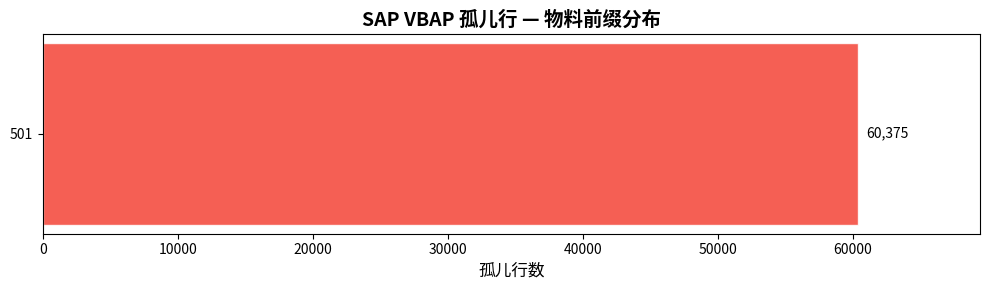

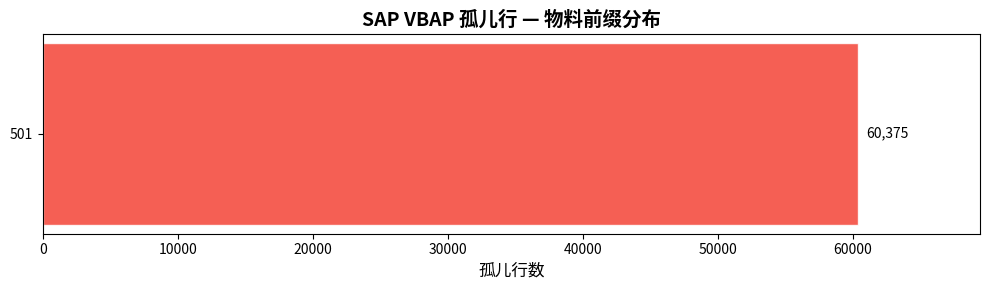

In [7]:
# 可视化：物料前缀分布
by = r_sap['by_mat_prefix'].set_index('物料前缀')['数量']
fig = plot_root_cause_distribution(by, title='SAP VBAP 孤儿行 — 物料前缀分布', xlabel='孤儿行数')
fig


### 2.2 PI 设备掉线（安全部）

In [8]:
# 加载 2022 年 1 月 PI 数据（约 446 万行）
pi = pd.read_parquet(f'{DATA_ROOT}/pi_system/tags_year=2022_month=01.parquet')
print(f"PI tags 全量: {len(pi):,} 行")

# 跑根因分析
r_pi = analyze_pi_missing_tags(pi)
print(f"\n[根因] 缺失行数 (status=-1): {r_pi['total_missing']:,} ({r_pi['missing_pct']:.3f}%)")
print(f"[根因] 缺失最多标签: {r_pi['top_tag']}")
print()
print("=== 缺失标签 Top 5 ===")
print(r_pi['by_tag'].head(5).to_string(index=False))


PI tags 全量: 4,464,000 行



[根因] 缺失行数 (status=-1): 22,216 (0.498%)
[根因] 缺失最多标签: M002_FACE_A_TEMP

=== 缺失标签 Top 5 ===
               标签  缺失数
 M002_FACE_A_TEMP  260
 M002_FACE_D_TEMP  257
   M005_FACE_B_CO  249
M002_FACE_D_WAGAS  249
 M001_FACE_A_TEMP  248


In [9]:
# [业务影响] 翻译成白话
print("[业务影响] PI 设备掉线（status=-1）")
print(f"  数字:  {len(pi):,} 行 × {r_pi['missing_pct']:.3f}% = {r_pi['total_missing']:,} 条/年")
print(f"  白话:  传感器掉线 = 采集网关断网，瓦斯/温度/CO 数据中断")
print(f"  根因:  缺失最多标签 {r_pi['top_tag']} — 检查该传感器网络连接和供电")
print(f"  责任:  安全部（参考 catalog.py SYSTEM_INFO）")


[业务影响] PI 设备掉线（status=-1）
  数字:  4,464,000 行 × 0.498% = 22,216 条/年
  白话:  传感器掉线 = 采集网关断网，瓦斯/温度/CO 数据中断
  根因:  缺失最多标签 M002_FACE_A_TEMP — 检查该传感器网络连接和供电
  责任:  安全部（参考 catalog.py SYSTEM_INFO）


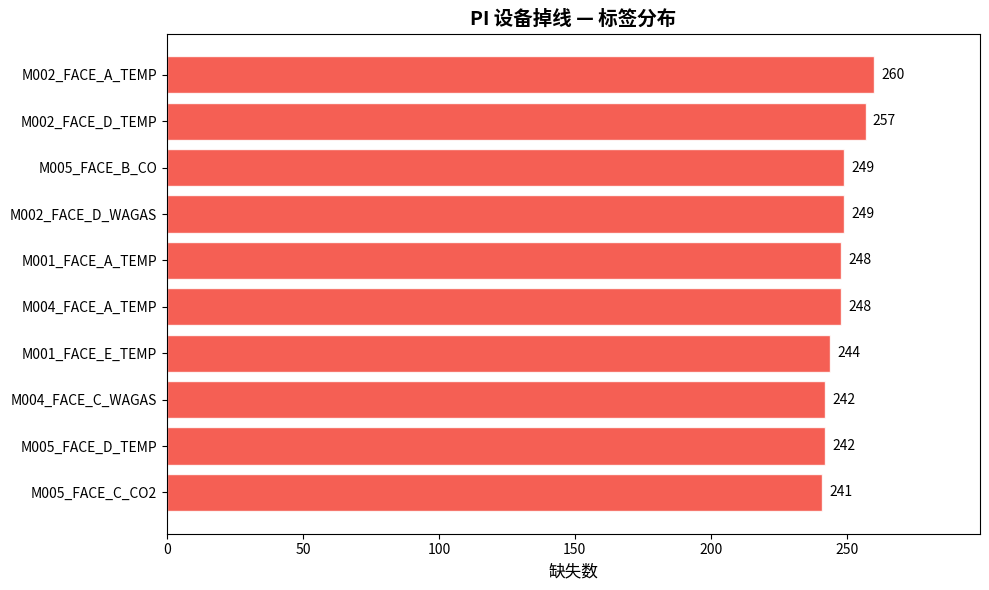

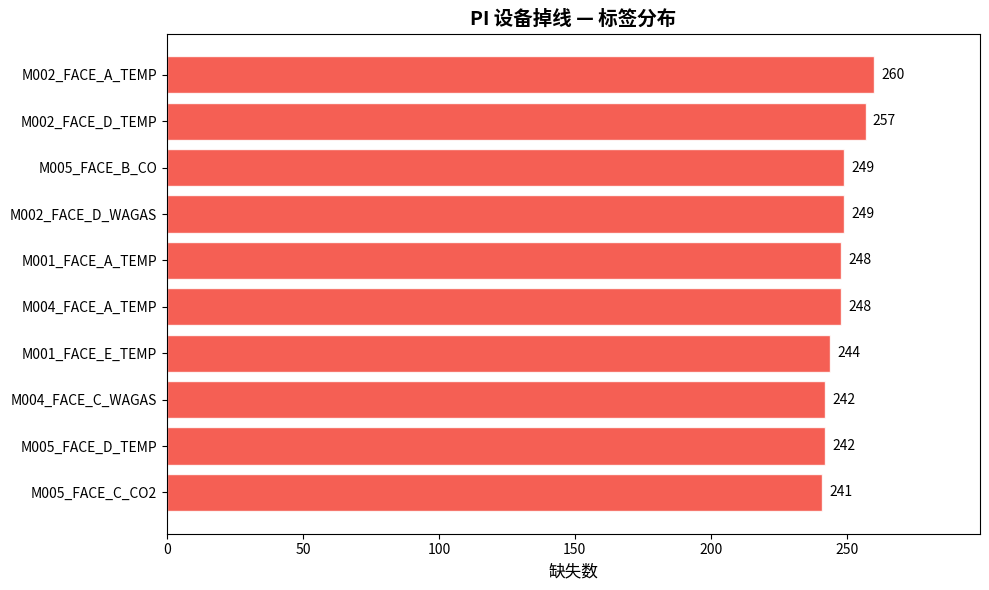

In [10]:
# 可视化：缺失标签分布
by = r_pi['by_tag'].set_index('标签')['缺失数']
fig = plot_root_cause_distribution(by, title='PI 设备掉线 — 标签分布', xlabel='缺失数')
fig


### 2.3 PI 瓦斯异常突升（安全部）

In [11]:
# 跑根因分析（3x 中位数基线）
r_anom = analyze_pi_anomalies(pi)
print(f"\n[根因] WAGAS 中位数基线: {r_anom['median_wagas']}")
print(f"[根因] 异常阈值 (3x): {r_anom['threshold']}")
print(f"[根因] 异常行数: {r_anom['total_anomalies']:,} ({r_anom['anomaly_pct']:.3f}%)")
print(f"[根因] 异常最多标签: {r_anom['top_tag']}")
print()
print("=== 异常标签 Top 5 ===")
print(r_anom['by_tag'].head(5).to_string(index=False))



[根因] WAGAS 中位数基线: 0.361
[根因] 异常阈值 (3x): 1.083
[根因] 异常行数: 1,868 (0.167%)
[根因] 异常最多标签: M003_FACE_C_WAGAS

=== 异常标签 Top 5 ===
               标签  异常数
M003_FACE_C_WAGAS   92
M001_FACE_B_WAGAS   89
M003_FACE_D_WAGAS   88
M002_FACE_C_WAGAS   85
M002_FACE_A_WAGAS   83


In [12]:
# [业务影响] 翻译成白话
print("[业务影响] PI 瓦斯异常突升（> 3x 中位数）")
print(f"  数字:  {r_anom['total_anomalies']:,} 条 WAGAS 读数 ({r_anom['anomaly_pct']:.3f}%)")
print(f"  白话:  异常突升可能意味着 (a) 传感器故障/漂移 或 (b) 真实瓦斯涌出")
print(f"  根因:  Top 标签 {r_anom['top_tag']} — 结合时间戳和现场人员判断 (a) vs (b)")
print(f"  责任:  安全部（参考 catalog.py SYSTEM_INFO）")


[业务影响] PI 瓦斯异常突升（> 3x 中位数）
  数字:  1,868 条 WAGAS 读数 (0.167%)
  白话:  异常突升可能意味着 (a) 传感器故障/漂移 或 (b) 真实瓦斯涌出
  根因:  Top 标签 M003_FACE_C_WAGAS — 结合时间戳和现场人员判断 (a) vs (b)
  责任:  安全部（参考 catalog.py SYSTEM_INFO）


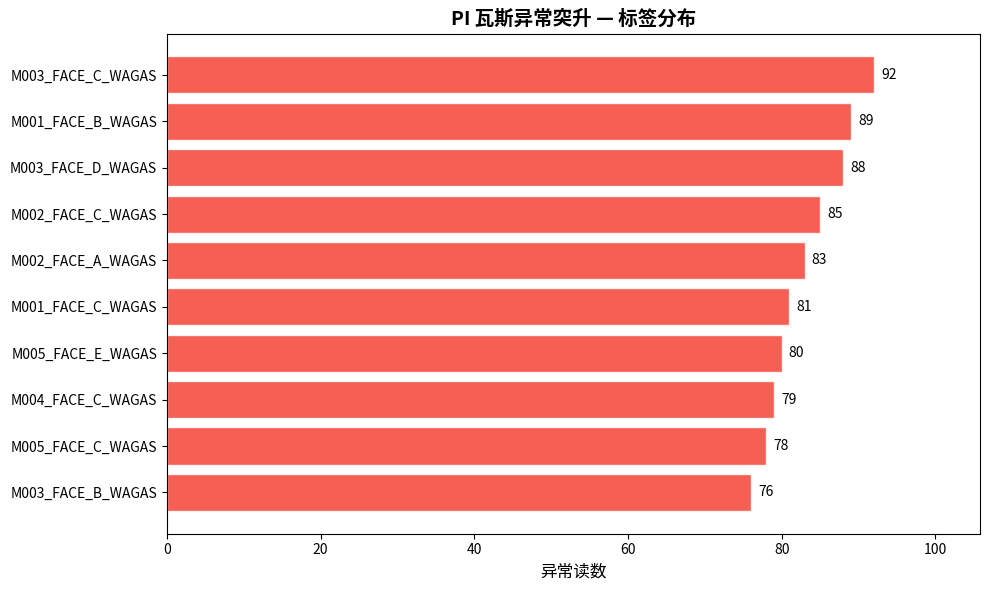

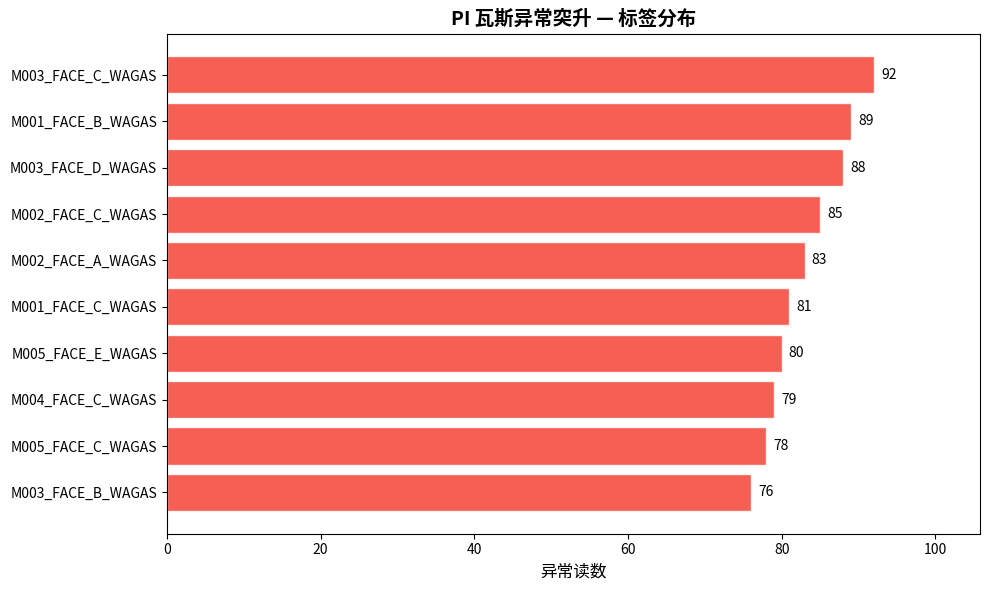

In [13]:
# 可视化：异常标签分布
by = r_anom['by_tag'].set_index('标签')['异常数']
fig = plot_root_cause_distribution(by, title='PI 瓦斯异常突升 — 标签分布', xlabel='异常读数')
fig


### 2.4 LIMS 灰分超煤种合理区间（煤质中心）

In [14]:
# 加载 2022 年全量 LIMS
lims = pd.read_parquet(f'{DATA_ROOT}/lims/samples_year=2022.parquet')
print(f"LIMS 全量: {len(lims):,} 行")

# 跑根因分析（按煤种判断）
r_lims = analyze_lims_ad_outliers(lims)
print(f"\n[根因] 灰分异常样品数: {r_lims['total_outliers']:,} ({r_lims['outlier_pct']:.3f}%)")
print(f"[根因] 异常最多煤种: {r_lims['top_sample_type']}")
print()
print("=== 各煤种异常数 ===")
print(r_lims['by_sample_type'].to_string(index=False))


LIMS 全量: 1,005,465 行

[根因] 灰分异常样品数: 25,243 (2.511%)
[根因] 异常最多煤种: 矸石

=== 各煤种异常数 ===
煤种  异常数   占比%
矸石 5150 0.512
洗煤 5114 0.509
精煤 5076 0.505
中煤 4967 0.494
原煤 4936 0.491


In [15]:
# [业务影响] 翻译成白话
print("[业务影响] LIMS 灰分超合理区间")
print(f"  数字:  {len(lims):,} 行 × {r_lims['outlier_pct']:.3f}% = {r_lims['total_outliers']:,} 条/年")
print(f"  白话:  灰分异常影响煤价定价（800 元/吨），需化验员复检")
print(f"  根因:  异常最多煤种 {r_lims['top_sample_type']} — 检查采样流程和化验操作")
print(f"  责任:  煤质中心（参考 catalog.py SYSTEM_INFO）")


[业务影响] LIMS 灰分超合理区间
  数字:  1,005,465 行 × 2.511% = 25,243 条/年
  白话:  灰分异常影响煤价定价（800 元/吨），需化验员复检
  根因:  异常最多煤种 矸石 — 检查采样流程和化验操作
  责任:  煤质中心（参考 catalog.py SYSTEM_INFO）


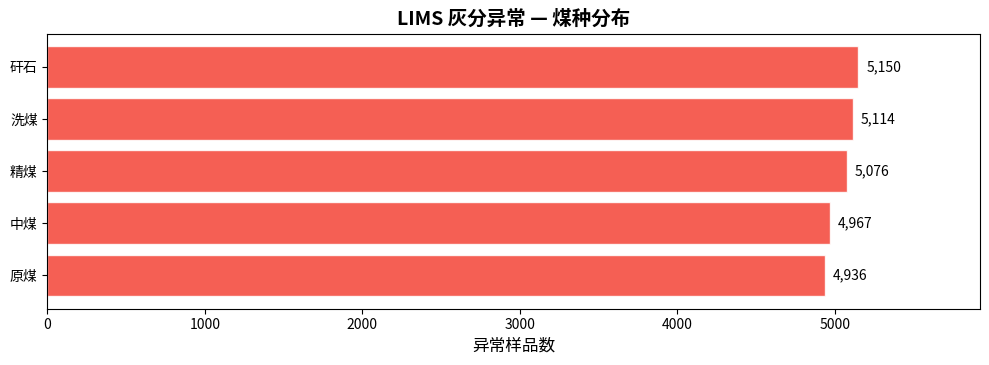

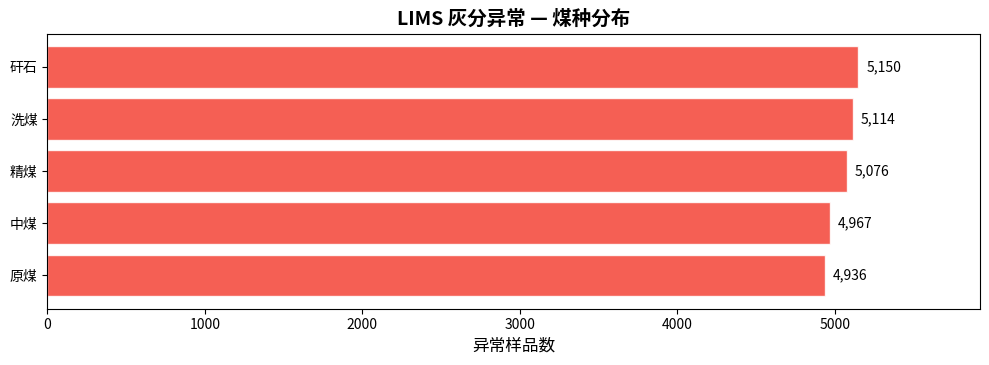

In [16]:
# 可视化：煤种异常分布
by = r_lims['by_sample_type'].set_index('煤种')['异常数']
fig = plot_root_cause_distribution(by, title='LIMS 灰分异常 — 煤种分布', xlabel='异常样品数')
fig


## 步骤 3：告警聚合 + 处置优先级

步骤 2 已经把每类告警的「数字 + 分布 + 责任部门」列清楚了。
但当同时有 6 类告警（4 类根因 + 其他 GE 规则）时，**老板会问「先处理谁」**。

这一步用**告警热力图**把 4 系统 × 6 告警的影响行数画成红黄绿热力图，
一眼看清「哪个系统、哪类问题最严重」。

In [17]:
# 构造 4 系统 × 5 告警的影响行数矩阵
alert_matrix = pd.DataFrame({
    'SAP孤儿行':      [r_sap['total_invalid'], 0, 0, 0],
    'PI设备掉线':     [0, r_pi['total_missing'], 0, 0],
    'PI瓦斯异常':     [0, r_anom['total_anomalies'], 0, 0],
    'LIMS灰分异常':   [0, 0, r_lims['total_outliers'], 0],
    'GE规则失败_其他': [
        sum(t.get('total', 0) - t.get('passed', 0) for t in report['results']['sap_erp']),
        sum(t.get('total', 0) - t.get('passed', 0) for t in report['results']['pi_system']),
        sum(t.get('total', 0) - t.get('passed', 0) for t in report['results']['lims']),
        sum(t.get('total', 0) - t.get('passed', 0) for t in report['results']['oa']),
    ],
}, index=['SAP-ERP', 'PI-System', 'LIMS', 'OA'])
print("=== 告警矩阵（行=系统，列=告警类型，值=影响行数）===")
print(alert_matrix)


=== 告警矩阵（行=系统，列=告警类型，值=影响行数）===
           SAP孤儿行  PI设备掉线  PI瓦斯异常  LIMS灰分异常  GE规则失败_其他
SAP-ERP     60375       0       0         0          4
PI-System       0   22216    1868         0          3
LIMS            0       0       0     25243          2
OA              0       0       0         0          1


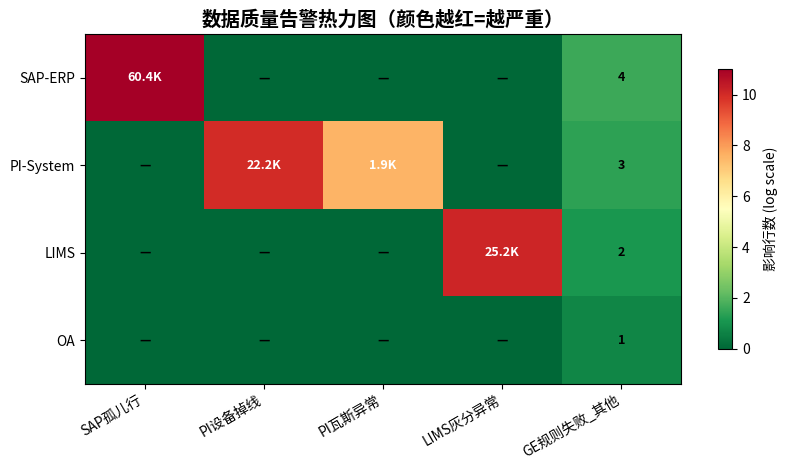

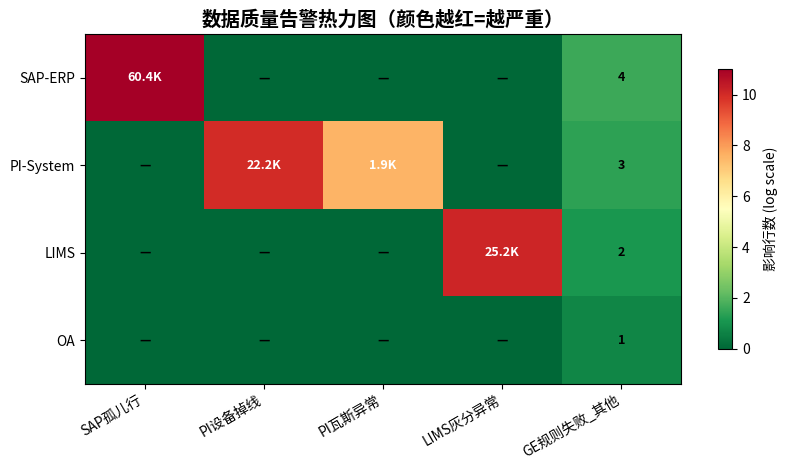

In [18]:
# 可视化：告警热力图（红=严重，黄=中等，绿=轻）
fig = plot_alert_heatmap(alert_matrix)
fig


In [19]:
# 处置优先级排名（按影响行数排序）
print("=== 处置优先级排名（按影响行数）===\n")
alerts = [
    ('SAP 孤儿行',      r_sap['total_invalid'],    '销售部'),
    ('PI 设备掉线',     r_pi['total_missing'],     '安全部'),
    ('PI 瓦斯异常突升', r_anom['total_anomalies'], '安全部'),
    ('LIMS 灰分异常',   r_lims['total_outliers'],  '煤质中心'),
]
alerts_sorted = sorted(alerts, key=lambda x: -x[1])
for i, (name, count, owner) in enumerate(alerts_sorted, 1):
    print(f"  {i}. {name:<20}  {count:>10,} 行  →  责任部门: {owner}")


=== 处置优先级排名（按影响行数）===

  1. SAP 孤儿行                   60,375 行  →  责任部门: 销售部
  2. LIMS 灰分异常                 25,243 行  →  责任部门: 煤质中心
  3. PI 设备掉线                   22,216 行  →  责任部门: 安全部
  4. PI 瓦斯异常突升                  1,868 行  →  责任部门: 安全部


## 附加：JSON 报告生成与复用

GE 扫描结果可以导出为 JSON 文件，供下游消费（如告警平台、BI 看板、定时任务）。
下面演示生成 JSON 报告 + 解析回去。

In [20]:
# 生成 JSON 报告（写到 notebooks/../data/quality_report_2022.json）
report_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'quality_report_2022.json')
report_json = run_ge_scan(output_json=report_path)
print(f"JSON 报告: {report_path}")
print(f"文件大小: {os.path.getsize(report_path):,} bytes")
print(f"综合平均分: {report_json['overall_avg_score']}")


JSON 报告: /home/szs/Playground/dg-demo/data/quality_report_2022.json
文件大小: 4,749 bytes
综合平均分: 64.9


In [21]:
# 解析 JSON 报告（用 parse_ge_report 函数）
from dg_education.ge_scan import parse_ge_report

loaded = parse_ge_report(report_path)
print(f"加载时间: {loaded['timestamp']}")
print(f"系统数: {len(loaded['results'])}")
print(f"汇总条目: {len(loaded['summary'])}")


加载时间: 2026-06-12T14:41:18.825470
系统数: 4
汇总条目: 4


## 模块二总结

走完 3 步学习节奏，我们已经达成：

| 步骤 | 达成 | 关键产出 |
|------|------|----------|
| ✅ 步骤 1 GE 全量扫描 | 4 系统 / 6 表 / A/B/C/D 等级 + 失败规则详情 | `run_ge_scan()` + `plot_system_alert_summary()` |
| ✅ 步骤 2 4 类根因定位 | 每类告警的影响行数 + 分布 + 责任部门 | `analyze_*` + `plot_root_cause_distribution()` |
| ✅ 步骤 3 告警聚合 | 热力图 + 处置优先级排名 | `plot_alert_heatmap()` |

### 关键发现（基于 2022 年全量数据）

1. **SAP-ERP** 评分 C（73.3%）：4 条规则失败，主要是 VBAP 孤儿行（6 万条）和 KNA1 STCD1 长度异常
2. **PI-System** 评分 D（40%）：3 条规则失败，status=-1 占 0.5% + value 范围问题
3. **LIMS** 评分 C（71.4%）：2 条规则失败，SAMPLE_ID 重复 23% + AD 范围 2.5%
4. **OA** 评分 C（75%）：1 条规则失败，AMOUNT 范围 60% 异常（业务规则偏严，可放宽）

### 下一步

模块二展示了「**找得到**」的能力：能定位具体行 + 责任部门。
下一步是「**改得了**」：

- 想了解「**数据怎么进 DataHub**」 → 打开 [`datahub_setup.ipynb`](./datahub_setup.ipynb)
- 想看模块一的「**资产可视化**」 → 打开 [`module1.ipynb`](./module1.ipynb)
- 想跑命令行 GE 扫描 → `uv run python scripts/run_great_expectations.py`